# Gibson's Paradox — a quantitative teardown 🔬
### Unit roots · Engle-Granger · a first-difference horse race · Clark-West · a duration overlay

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim
(Keynes 1930): long yields co-move with the **price level**, not with **inflation**. The tests
that carry the verdict are §3 (cointegration), §4 (differences, Newey-West), §5 (the
adaptive-expectations confound) and §6 (out of sample + the overlay). §7 is the synthetic
two-world control — a machinery proof, never market evidence.

> ⚠️ **Not investment advice.** Real tapes frozen inside `arch` / `statsmodels` (SHA-256 pinned
> through `quantlab.bundled`), as-of 2018-11-30; fingerprints US `d269fafaad79`, US quarterly
> `c617cf170e24`, Germany `1ac0ebf245e1`. Numbers in prose mirror
> [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
warnings.simplefilter("ignore")
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 160)
from gibson import data, strategy as st
us = data.load_us_monthly()
us["ewma"] = st.adaptive_expectation(us["pi_1m"], 36)
de = data.load_germany()
uq = data.load_us_quarterly()
print(f"US monthly {us.index[0]:%Y-%m} -> {us.index[-1]:%Y-%m} | fingerprint "
      f"{data.fingerprint(us[['aaa', 'baa', 'cpi', 'rf']])}")
print(f"Germany    {de.index[0]:%Y-%m} -> {de.index[-1]:%Y-%m} | fingerprint "
      f"{data.fingerprint(de[['R', 'Dp']])}")

US monthly 1957-01 -> 2018-11 | fingerprint d269fafaad79
Germany    1972-06 -> 1998-12 | fingerprint 1ac0ebf245e1


## Verdict, up front (real tape)

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Mixed | **Signal: Mixed** — *a US-only shadow of Fisher.* On the US tape the detrended price level beats 12-month inflation in first differences (Newey-West t +3.56 vs +0.38) and out of sample (Clark-West p 0.000); in Germany 1972-98 it shows nothing (t +0.07). Yields are **not** cointegrated with the price gap (Engle-Granger p 0.19) but **are** with a slow, adaptive inflation expectation (p 0.009) — Fisher's own 1930 explanation of the paradox. Detrend over a rolling 10-year window instead and the forecasting edge vanishes (p 0.82). |
| **Tradability** | Fragile | **Tradability: Fragile.** A duration overlay on a 20-year AAA bond earns +1.95% a year net over constant duration (t +2.63; net Sharpe 0.54 vs 0.50), but it sits at 1.43× duration on average, trades 0.13× a year, has an alpha of only +0.65% (t +1.01) after its extra duration, and made -0.05% a year in 1965-81 against +2.44% in 1982-2018. One secular trade, not a repeatable rule. |

> 💡 **In plain words.** The US data do contain a Gibson-looking pattern, but it is best
> explained by investors' slow-moving inflation expectations, it is absent in Germany, and the
> trading rule it implies was one long bet that happened to be right.

## 1 · Hypotheses and pre-registered rules

Variables: *Y* = Moody's AAA yield (%), *p* = 100·log core CPI, gap = *p* minus a past-only
linear trend (expanding from 1957; rolling 10-year as robustness), π = 12-month log inflation.

For each side — **Gibson** (gap) and **Fisher** (π) — three legs:

- **L1** Engle-Granger p < 0.05 for *Y* on the variable.
- **L2** Newey-West t ≥ 2 on the variable's slope in the *joint* regression ΔY = a + b·Δgap + c·Δπ.
- **L3** Clark-West one-sided p < 0.05 for adding the variable (lagged one month for CPI
  publication) to a yield-only expanding-window forecast of Y[t+12] − Y[t].

**Signal** (`signal_stamp`): *Real* = US has L2 and (L1 or L3) **and** Germany passes ≥ 1 leg;
*Mixed* = one tape strong, the other nothing; *Weak* = any leg anywhere; *None* = no leg.
**Tradability** (`trad_stamp`): *Investable* = overlay net − constant HAC t ≥ 2, positive in both
regimes, beats the yield-only timer, with a Real/Mixed signal; *Fragile* = positive net edge and
higher net Sharpe; else *Mirage*.

## 2 · Levels and unit roots

In [2]:
cols = ("logp", "gap_exp", "gap_rol", "pi", "ewma")
rows = []
for name, (a, b) in {"1957-2018": (None, None), "1965-81": data.GREAT_INFLATION,
                     "1982-2018": data.DISINFLATION}.items():
    rows.append({"tape": "US", "period": name, **st.level_correlations(us, "aaa", cols, a, b)})
rows.append({"tape": "US quarterly (headline)", "period": "1959-2009",
             **st.level_correlations(uq, "aaa", cols[:4])})
rows.append({"tape": "Germany", "period": "1972-98", **st.level_correlations(de, "R", cols[:4])})
print("Correlation of the long yield with... (descriptive only)")
print(pd.DataFrame(rows).set_index(["tape", "period"]).round(2).to_string())
ur = st.unit_root_table({"AAA": us["aaa"], "ΔAAA": us["aaa"].diff(), "log CPI": us["logp"],
                         "1m inflation": us["pi_1m"], "12m inflation": us["pi"],
                         "gap (expanding)": us["gap_exp"], "gap (rolling)": us["gap_rol"],
                         "adaptive exp. 36m": us["ewma"], "DE R": de["R"], "DE 4q infl": de["pi"]})
print(); print(ur[["n", "adf_p", "kpss_p", "i1_like"]].round(3).to_string())

Correlation of the long yield with... (descriptive only)
                                    logp  gap_exp  gap_rol    pi  ewma
tape                    period                                        
US                      1957-2018 -0.000    0.800    0.030 0.750 0.910
                        1965-81    0.920    0.950    0.500 0.860 0.940
                        1982-2018 -0.960    0.960   -0.460 0.870 0.960
US quarterly (headline) 1959-2009  0.230    0.670   -0.090 0.590   NaN
Germany                 1972-98   -0.580    0.440    0.440 0.700   NaN



                     n  adf_p  kpss_p  i1_like
series                                        
AAA                743  0.548   0.010     True
ΔAAA               742  0.000   0.100    False
log CPI            743  0.594   0.010     True
1m inflation       742  0.078   0.010     True
12m inflation      731  0.056   0.010     True
gap (expanding)    684  0.932   0.010     True
gap (rolling)      624  0.008   0.010    False
adaptive exp. 36m  742  0.566   0.010     True
DE R               107  0.327   0.010     True
DE 4q infl         104  0.561   0.010     True


> 💡 **In plain words.** Every level that matters drifts like a random walk — ADF cannot
> reject a unit root, KPSS rejects stationarity. Level correlations between such series are the
> textbook spurious regression, so the table above is a description of the claim, not evidence.
> Note also that if inflation is I(1) the log price level is I(2): a raw price level cannot be
> cointegrated with an I(1) yield at all, which is why only the detrended gap is a fair test.

## 3 · Cointegration — Engle-Granger

   tape              Y on  slope  naive t    R2  EG p
     US     raw log price -0.000   -0.131 0.000 0.770
     US   gap (expanding)  0.132   36.848 0.647 0.194
     US gap (rolling 10y)  0.025    0.639 0.001 0.839
     US     12m inflation  0.815   24.447 0.562 0.275
     US adaptive exp. 36m  1.370   61.423 0.831 0.009
Germany   gap (expanding)  0.364    4.191 0.195 0.377
Germany      4q inflation  0.690   12.910 0.492 0.087


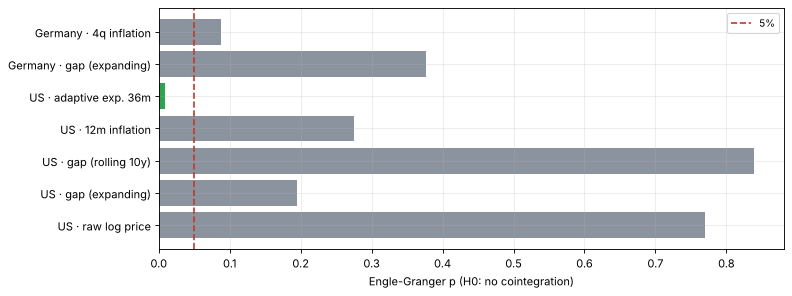

In [3]:
rows = []
for lab, x in (("raw log price", us["logp"]), ("gap (expanding)", us["gap_exp"]),
               ("gap (rolling 10y)", us["gap_rol"]), ("12m inflation", us["pi"]),
               ("adaptive exp. 36m", us["ewma"])):
    r = st.engle_granger(us["aaa"], x)
    rows.append({"tape": "US", "Y on": lab, "slope": r["slope"], "naive t": r["naive_t"],
                 "R2": r["r2"], "EG p": r["eg_p"]})
for lab, x in (("gap (expanding)", de["gap_exp"]), ("4q inflation", de["pi"])):
    r = st.engle_granger(de["R"], x)
    rows.append({"tape": "Germany", "Y on": lab, "slope": r["slope"], "naive t": r["naive_t"],
                 "R2": r["r2"], "EG p": r["eg_p"]})
eg = pd.DataFrame(rows)
print(eg.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.barh(eg["tape"] + " · " + eg["Y on"], eg["EG p"],
        color=["#2ea44f" if p < 0.05 else "#8b949e" for p in eg["EG p"]])
ax.axvline(0.05, color="#c0392b", ls="--", lw=1.5, label="5%")
ax.set_xlabel("Engle-Granger p (H0: no cointegration)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> 💡 **In plain words.** The naive t-statistics are enormous; the cointegration tests are
> not impressed — except for the slow inflation expectation. The yield has a genuine long-run
> anchor, and it is Fisher's, with a long memory.

## 4 · First differences — the horse race

In [4]:
rows = []
for name, (a, b) in {"1957-2018": (None, None), "1965-81": data.GREAT_INFLATION,
                     "1982-2018": data.DISINFLATION}.items():
    rows.append({"tape": "US AAA", "period": name,
                 **st.diff_horse_race(us, "aaa", "gap_exp", "pi", 12, a, b)})
rows.append({"tape": "US BAA", "period": "1957-2018",
             **st.diff_horse_race(us, "baa", "gap_exp", "pi", 12)})
rows.append({"tape": "US quarterly (headline)", "period": "1959-2009",
             **st.diff_horse_race(uq, "aaa", "gap_exp", "pi", 4)})
rows.append({"tape": "Germany", "period": "1972-98",
             **st.diff_horse_race(de, "R", "gap_exp", "pi", 4)})
hr = pd.DataFrame(rows).set_index(["tape", "period"])
print(hr[["n", "b_gap", "t_gap", "b_pi", "t_pi", "t_gap_alone", "t_pi_alone"]].round(3).to_string())
rd = st.regime_difference(us, "aaa", data.GREAT_INFLATION, data.DISINFLATION)
print(f"\ngap slope, 1982-2018 minus 1965-81: {rd['diff_gap']:+.3f} (HAC t {rd['t_diff_gap']:+.2f})")

                                     n  b_gap  t_gap   b_pi   t_pi  t_gap_alone  t_pi_alone
tape                    period                                                             
US AAA                  1957-2018  683  0.231  3.565  0.028  0.378        4.253       2.549
                        1965-81    204  0.221  2.369  0.006  0.056        2.482       1.645
                        1982-2018  443  0.184  1.590  0.124  1.272        2.359       2.193
US BAA                  1957-2018  683  0.328  3.998 -0.009 -0.166        5.779       4.369
US quarterly (headline) 1959-2009  183  0.311  3.665  0.021  0.363        4.761       3.845
Germany                 1972-98     84  0.016  0.074 -0.126 -0.998       -0.428      -1.132

gap slope, 1982-2018 minus 1965-81: -0.038 (HAC t -0.25)


> 💡 **In plain words.** In changes, the US yield responds to this month's price move
> (which *is* this month's inflation) more than to the change in the 12-month inflation rate — on
> core and headline CPI, for AAA and BAA. Germany shows nothing. The regime split is not
> significant, so we do not claim the effect "faded".

## 5 · The confound — Fisher with a long memory

               corr level  EG p  corr(Δgap, Δexp)  t gap (joint)  t exp (joint)
half-life (m)                                                                  
12                  0.838 0.151             0.905          1.710          0.031
36                  0.912 0.009             0.982          1.277          0.041
60                  0.910 0.008             0.974          1.532          0.080
120                 0.862 0.077             0.922          1.580          0.090


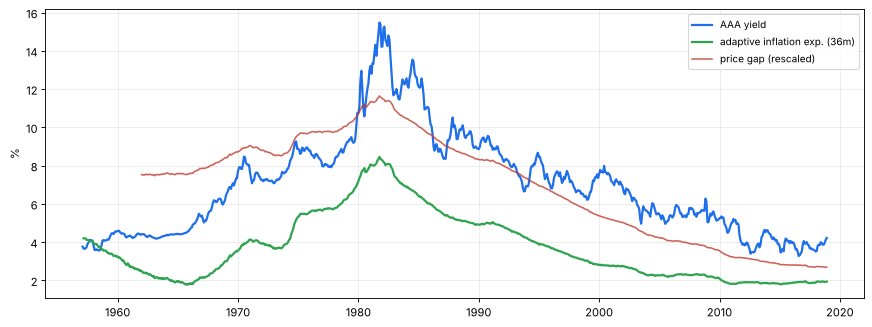

In [5]:
rows = []
for hl in (12, 36, 60, 120):
    e = st.adaptive_expectation(us["pi_1m"], hl)
    dd = us.assign(ew=e)
    r = st.diff_horse_race(dd, "aaa", "gap_exp", "ew", 12)
    ch = dd[["gap_exp", "ew"]].diff().dropna()
    rows.append({"half-life (m)": hl, "corr level": us["aaa"].corr(e),
                 "EG p": st.engle_granger(us["aaa"], e)["eg_p"],
                 "corr(Δgap, Δexp)": ch["gap_exp"].corr(ch["ew"]),
                 "t gap (joint)": r["t_gap"], "t exp (joint)": r["t_pi"]})
lm = pd.DataFrame(rows).set_index("half-life (m)")
print(lm.round(3).to_string())
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(us.index, us["aaa"], color="#1f6feb", lw=2, label="AAA yield")
z = us["ewma"]; ax.plot(us.index, z, color="#2ea44f", lw=2, label="adaptive inflation exp. (36m)")
g = us["gap_exp"]; sc = us["aaa"].std() / g.std()
ax.plot(us.index, (g - g.mean()) * sc + us["aaa"].mean(), color="#c0392b", lw=1.4, alpha=0.8,
        label="price gap (rescaled)")
ax.legend(fontsize=9); ax.set_ylabel("%"); plt.tight_layout(); plt.show()

> 💡 **In plain words.** The whole half-life grid is shown, not a chosen point. In changes,
> the price gap and a slow inflation expectation are almost the same series (correlation ≥ 0.9),
> so no regression can tell them apart; in levels, the expectation fits better *and* is
> cointegrated with the yield. Fisher (1930) and Sargent (1973) read Gibson exactly this way.

## 6 · Out of sample, and the overlay

### 6.1 Expanding-window forecasts with Clark-West

In [6]:
lag = st.add_publication_lag(us, cols=("gap_exp", "gap_rol", "pi", "ewma"))
tabs, fcs = [], {}
for h in (3, 12):
    t, fc = st.oos_table(lag, "aaa", h, 120, variables=("gap_exp", "gap_rol", "pi", "ewma"))
    tabs.append(t.assign(tape="US")); fcs[h] = fc
lde = st.add_publication_lag(de, cols=("gap_exp", "pi"))
for h in (1, 4):
    t, _ = st.oos_table(lde, "R", h, 40, variables=("gap_exp", "pi"))
    tabs.append(t.assign(tape="Germany"))
oos = pd.concat(tabs).reset_index()
print(oos[["tape", "h", "variable", "n", "oos_r2_vs_yield_only", "cw_t", "cw_p",
           "yield_only_oos_r2_vs_mean"]].round(3).to_string(index=False))

   tape  h variable   n  oos_r2_vs_yield_only   cw_t  cw_p  yield_only_oos_r2_vs_mean
     US  3  gap_exp 558                 0.014  3.791 0.000                     -0.032
     US  3  gap_rol 498                -0.009  0.594 0.276                     -0.067
     US  3       pi 605                 0.032  2.167 0.015                     -0.033
     US  3     ewma 616                 0.036  4.208 0.000                     -0.034
     US 12  gap_exp 540                 0.035  4.453 0.000                     -0.183
     US 12  gap_rol 480                -0.092 -0.919 0.821                     -0.355
     US 12       pi 587                 0.069  2.283 0.011                     -0.208
     US 12     ewma 598                 0.086  3.677 0.000                     -0.202
Germany  1  gap_exp  43                -0.365 -1.785 0.963                     -0.052
Germany  1       pi  62                -0.023 -0.113 0.545                     -0.059
Germany  4  gap_exp  37                -0.823 -1.270 0

> 💡 **In plain words.** The full-history gap forecasts in real time; the 10-year-trend gap
> does not; the slow expectation does as well as the gap. Germany's ~40-60 forecasts show nothing.
> Note that the yield-only model loses to the prevailing mean (negative last column): the
> benchmark is beatable, which flatters any added variable a little.

### 6.2 The duration overlay

Bond return (stated): r[t+1] ≈ Y[t]/12 − D[t]·ΔY + ½·C[t]·ΔY², D and C of a 20-year semi-annual
par bond at the AAA yield. Weight 1.5× when the 12-month forecast is below the prevailing mean
change, else 0.5×; set at *t*, earns *t+1*; CPI lagged a month; 5 bp one-way × NAV traded.
Benchmark 1× constant duration; all excess of the T-bill.

In [7]:
bond = st.bond_returns(us["aaa"], us["rf"])
fc12 = fcs[12]
splits = {"1965-81": data.GREAT_INFLATION, "1982-2018": data.DISINFLATION}
bts = {v: st.timing_backtest(bond, st.timing_positions(fc12[v]), 5.0)
       for v in ("gap_exp", "gap_rol", "pi", "ewma")}
bts["yield_only"] = st.timing_backtest(bond, st.timing_positions(fc12["gap_exp"], "f_base"), 5.0)
rows = []
for v, bt in bts.items():
    s = st.timing_summary(bt, splits=splits)
    rows.append({"timer": v, "net Sharpe": s["net"]["sharpe"], "const Sharpe": s["const"]["sharpe"],
                 "net-const /yr": s["diff_net_ann"], "HAC t": s["diff_net_t"],
                 "mean pos": s["mean_pos"], "turnover/yr": s["turnover_ann"],
                 "alpha /yr": s["alpha_ann"], "alpha t": s["alpha_t"],
                 **{f"{k} net-const": x["diff_net_ann"] for k, x in s["subs"].items()}})
print(pd.DataFrame(rows).set_index("timer").round(3).to_string())
g, y = bts["gap_exp"], bts["yield_only"]
c = g.index.intersection(y.index)
m = st.hac_mean(g.loc[c, "net"] - y.loc[c, "net"], 12)
print(f"\ngap timer minus yield-only timer: {m['mean']*12:+.2%} /yr (t {m['t']:+.2f})")
sweep = []
for cb in (0, 2, 5, 10, 25, 50):
    s = st.timing_summary(st.timing_backtest(bond, st.timing_positions(fc12["gap_exp"]), cb))
    sweep.append({"cost bp": cb, "net-const /yr": s["diff_net_ann"], "t": s["diff_net_t"]})
print(pd.DataFrame(sweep).round(4).to_string(index=False))

            net Sharpe  const Sharpe  net-const /yr  HAC t  mean pos  turnover/yr  alpha /yr  alpha t  1965-81 net-const  1982-2018 net-const
timer                                                                                                                                        
gap_exp          0.544         0.503          0.020  2.626     1.431        0.131      0.006    1.008             -0.001                0.024
gap_rol          0.317         0.543         -0.019 -2.459     0.777        0.122     -0.012   -1.403             -0.041               -0.017
pi               0.541         0.482          0.011  1.473     1.097        0.401      0.009    1.370             -0.005                0.016
ewma             0.507         0.464          0.010  1.463     1.160        0.571      0.008    1.178             -0.002                0.015
yield_only       0.366         0.503         -0.013 -1.642     0.858        0.109     -0.005   -0.633             -0.010               -0.013

gap t

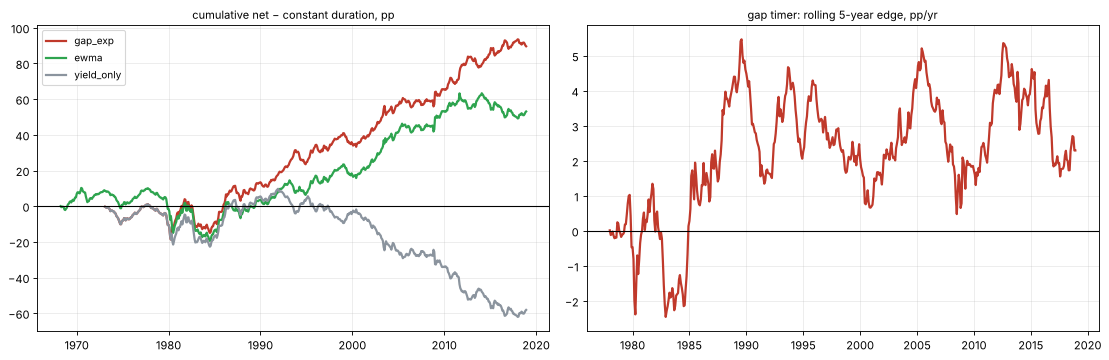

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
for v, col in (("gap_exp", "#c0392b"), ("ewma", "#2ea44f"), ("yield_only", "#8b949e")):
    bt = bts[v]
    ax.plot(bt.index, (bt["net"] - bt["const"]).cumsum() * 100, color=col, lw=2, label=v)
ax.axhline(0, color="k", lw=1); ax.legend(fontsize=9)
ax.set_title("cumulative net − constant duration, pp", fontsize=10)
ax = axes[1]
g = bts["gap_exp"]
roll = (g["net"] - g["const"]).rolling(60).mean() * 12 * 100
ax.plot(roll.index, roll, color="#c0392b", lw=2)
ax.axhline(0, color="k", lw=1)
ax.set_title("gap timer: rolling 5-year edge, pp/yr", fontsize=10)
plt.tight_layout(); plt.show()

> 💡 **In plain words.** Costs are irrelevant — the rule barely trades. What matters is
> that it held ~1.4× duration through a 35-year bond rally and earned nothing in 1965-81. After
> regressing on constant duration the alpha is not significant. Fragile: real money on paper,
> one bet in substance.

## 7 · Synthetic control — Fisher world vs Gibson world (machinery proof)

Same simulated price path; the yield follows Fisher (s = 0), Gibson (s = 1) or a blend. The
detectors must fire in their own world and stay quiet in the other. **Not market evidence.**

       t gap  t infl  EG p gap  EG p infl
s                                        
0.000  0.416   7.712     0.911      0.011
0.250  1.268   5.308     0.816      0.002
0.500  2.120   2.905     0.441      0.022
0.750  2.972   0.502     0.040      0.168
1.000  3.824  -1.901     0.002      0.328


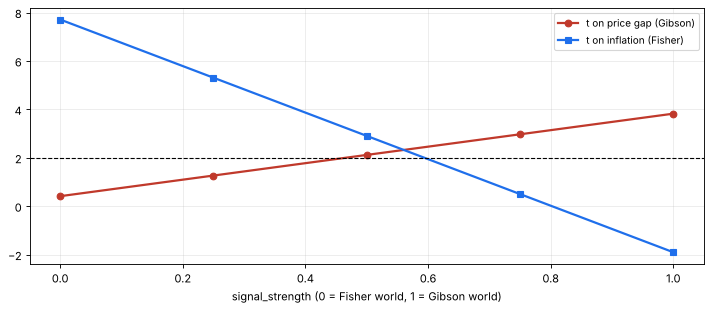

In [9]:
rows = []
for s_ in (0.0, 0.25, 0.5, 0.75, 1.0):
    w, _ = data.synthetic_world(n_months=600, signal_strength=s_, seed=1026)
    hr_ = st.diff_horse_race(w, "aaa", "gap_exp", "pi", 12)
    rows.append({"s": s_, "t gap": hr_["t_gap"], "t infl": hr_["t_pi"],
                 "EG p gap": st.engle_granger(w["aaa"], w["gap_exp"])["eg_p"],
                 "EG p infl": st.engle_granger(w["aaa"], w["pi"])["eg_p"]})
syn = pd.DataFrame(rows).set_index("s")
print(syn.round(3).to_string())
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(syn.index, syn["t gap"], "o-", color="#c0392b", lw=2, label="t on price gap (Gibson)")
ax.plot(syn.index, syn["t infl"], "s-", color="#1f6feb", lw=2, label="t on inflation (Fisher)")
ax.axhline(2, color="k", ls="--", lw=1)
ax.set_xlabel("signal_strength (0 = Fisher world, 1 = Gibson world)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> 💡 **In plain words.** The harness can tell the two worlds apart: the Gibson t rises with
> the planted strength and the Fisher t falls. So the real-tape result — a Gibson-looking
> difference signal *and* Fisher-type cointegration — is a finding about the data, not a blind spot
> of the tests.

## 8 · Caveats

- **No gold standard on these tapes** (no price index before 1957). The paradox's home era is
  untested; this is the fiat-era version only.
- **Moody's AAA** is a seasoned corporate index with drifting maturity and a credit spread; the
  par-bond return is an approximation, and a real overlay would use Treasury futures (basis risk).
- **Final-vintage macro**; core CPI lagged one month for publication.
- **Specification sensitivity**: expanding vs rolling detrend changes the forecasting answer.
- **Germany is short** — low power, but no hint of the effect either.

## 9 · Going further 🚪

- A pre-1914 price index would let the same harness test the gold standard directly.
- Survey expectations (SPF, Michigan) in place of the exponential average.
- A cross-country fiat-era panel for a properly powered second leg.
- Fork `gibson/strategy.py`: every leg is a function, every threshold is a named rule.